# `E_macro` — Key Findings Across Six Pillars

**Decision on the table:** which pillars earn their place in the fused embedding,
which get changed, and which get cut.

Every number below is recomputed from `data/*.parquet` or read from the
per-source `stats.json` bundles written by the analysis scripts.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
DATA = REPO / "data"
ANALYSIS = REPO / "analysis-output"

mpl.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 110,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

INK = "#1f2a37"
ACCENT = "#c2410c"
MUTED = "#9ca3af"
GOOD = "#15803d"

In [2]:
# --- load all six pillars -------------------------------------------------
src = {
    "A": pd.read_parquet(DATA / "source_a_embeddings.parquet"),
    "B": pd.read_parquet(DATA / "source_b_qcew.parquet"),
    "C": pd.read_parquet(DATA / "source_c_fred.parquet"),
    "D": pd.read_parquet(DATA / "source_d_faf.parquet"),
    "E": pd.read_parquet(DATA / "source_e_irs_soi.parquet"),
    "F": pd.read_parquet(DATA / "source_f_usda_typology.parquet"),
}

STATS_FILES = {
    "A": "source-a/stats.json",
    "B": "source-b/source_b_stats.json",
    "C": "source-c/source_c_stats.json",
    "D": "source-d/source_d_stats.json",
    "E": "source-e/source_e_stats.json",
    "F": "source-f/source_f_stats.json",
}
stats = {k: json.loads((ANALYSIS / v).read_text()) for k, v in STATS_FILES.items()}

for k, df in src.items():
    print(f"Source {k}: {len(df):>5,} counties x {df.shape[1]:>2} cols")

Source A: 3,144 counties x  5 cols
Source B: 3,143 counties x 42 cols
Source C: 3,144 counties x  8 cols
Source D: 3,144 counties x 16 cols
Source E: 3,143 counties x  8 cols
Source F: 3,144 counties x 21 cols


In [3]:
# --- one joined frame on fips_code ---------------------------------------
# Source C's gdp_velocity is dollar-denominated; normalize by level so it
# ranks fast movers rather than big economies (see Section 4).
c = src["C"].copy()
c["gdp_velocity_pct"] = c["gdp_velocity"] / c["gdp_latest"]

panel = (
    src["F"][["fips_code", "county_name", "metro_2023",
              "low_postsecondary_ed", "low_employment", "population_loss",
              "housing_stress", "retirement_destination", "persistent_poverty"]]
    .merge(c[["fips_code", "unemployment_velocity", "gdp_velocity",
              "gdp_velocity_pct", "gdp_latest"]], on="fips_code", how="left")
    .merge(src["D"][["fips_code", "total_outbound_tons", "total_inbound_tons",
                     "out_partner_hhi"]], on="fips_code", how="left")
    .merge(src["E"][["fips_code", "capital_to_wage_ratio", "num_returns"]],
           on="fips_code", how="left")
)

DISTRESS_FLAGS = ["low_postsecondary_ed", "low_employment", "population_loss",
                  "housing_stress", "retirement_destination", "persistent_poverty"]
panel["distress_count"] = panel[DISTRESS_FLAGS].astype("float").sum(axis=1)
panel["total_tons"] = panel["total_outbound_tons"] + panel["total_inbound_tons"]
panel["log_tons"] = np.log10(panel["total_tons"].clip(lower=1))

print(f"panel: {len(panel):,} counties x {panel.shape[1]} cols")
print(f"complete velocity rows: {panel['gdp_velocity_pct'].notna().sum():,}")

panel: 3,144 counties x 21 cols
complete velocity rows: 3,080


---

## 1. Verdict scorecard

One row per pillar. The "deciding evidence" column is the single number that
drives the verdict; each is unpacked in its own section below.

In [4]:
from scipy.stats import pearsonr

# The cross-source scripts emit CSVs rather than stats.json, so the two
# pillar-to-pillar effect sizes are recomputed here from those tables.
OUTPUTS = REPO / "outputs"

af = pd.read_csv(OUTPUTS / "source_a_source_f_crossvalidation.csv")
F_x_A_R, _ = pearsonr(af["metro_2023"].astype(int), af["content_length"])

df_ = pd.read_csv(OUTPUTS / "source_d_source_f_crossvalidation.csv").dropna(
    subset=["total_tons", "distress_count"])
F_x_D_R, _ = pearsonr(df_["distress_count"], np.log10(df_["total_tons"].clip(lower=1)))

# Permutation p-values (499 perms) from the cross-source reports; the Mantel
# test against economic distance is too costly to rerun live.
F_x_D_P = F_x_A_P = 0.0020
A_GEO_R = stats["A"]["mantel_r"]      # embedding similarity vs geography
A_ECON_R = -0.0406                    # embedding similarity vs economic distance
B_BEST_SECTOR_R = 0.206               # Real Estate & Rental & Leasing LQ vs GDP velocity

scorecard = pd.DataFrame([
    dict(
        Pillar="A — Wikipedia embeddings",
        Measures="Narrative / identity",
        Evidence=f"Mantel r = {A_GEO_R:.3f} vs geography, but {A_ECON_R:.3f} vs economics; "
                 f"text *length* vs metro r = {F_x_A_R:.3f}",
        Verdict="CUT the embedding",
    ),
    dict(
        Pillar="B — QCEW location quotients",
        Measures="Industrial core",
        Evidence=f"magnitude r = {stats['B']['dominant_lq_vs_gdp_velocity_pct_corr']:.3f}, "
                 f"but best single sector r = {B_BEST_SECTOR_R:.3f}",
        Verdict="KEEP — change the feature",
    ),
    dict(
        Pillar="C — FRED velocity",
        Measures="Economic momentum",
        Evidence=f"its own two velocities correlate r = {stats['C']['velocity_correlation']:.3f}; "
                 f"{stats['C']['quadrant_counts']['Growing but Loosening'] / stats['C']['quadrant_n_counties']:.1%} "
                 "of counties in one quadrant",
        Verdict="KEEP — fix the metric",
    ),
    dict(
        Pillar="D — FAF freight tonnage",
        Measures="Trade gravity",
        Evidence="GDP velocity rises monotonically across tonnage quartiles "
                 f"({stats['D']['gdp_velocity_pct_by_tons_quartile']['1']:.1%} → "
                 f"{stats['D']['gdp_velocity_pct_by_tons_quartile']['4']:.1%}), p = "
                 f"{stats['D']['log_tons_vs_gdp_velocity_pct_p']:.3f}",
        Verdict="KEEP — best performer",
    ),
    dict(
        Pillar="E — IRS capital ratio",
        Measures="Capital composition",
        Evidence=f"r = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_corr']:.3f} "
                 f"(p = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_p']:.3f}); "
                 "monotone quartiles, but low-return counties are one-time-sale noise",
        Verdict="KEEP — weight by returns",
    ),
    dict(
        Pillar="F — USDA typology",
        Measures="Structural resilience",
        Evidence=f"distress vs velocity p = {stats['F']['distress_vs_unemployment_velocity_p']:.2f} (null), "
                 f"but distress vs freight r = {F_x_D_R:.3f} (p = {F_x_D_P:.3f})",
        Verdict="KEEP — reclassify as covariate",
    ),
])

VERDICT_COLORS = {
    "CUT the embedding": "background-color: #fee2e2; color: #991b1b; font-weight: 700",
    "KEEP — best performer": "background-color: #dcfce7; color: #166534; font-weight: 700",
}
DEFAULT_VERDICT = "background-color: #fef3c7; color: #92400e; font-weight: 700"

(scorecard.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top",
                       "font-size": "13px", "padding": "10px"})
    .set_properties(subset=["Pillar"], **{"font-weight": "700"})
    .map(lambda v: VERDICT_COLORS.get(v, DEFAULT_VERDICT), subset=["Verdict"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "10px")]},
        {"selector": "", "props": [("border-collapse", "collapse")]},
    ])
    .set_caption("E_macro pillar scorecard — six sources, one verdict each"))

Pillar,Measures,Evidence,Verdict
A — Wikipedia embeddings,Narrative / identity,"Mantel r = -0.236 vs geography, but -0.041 vs economics; text *length* vs metro r = 0.247",CUT the embedding
B — QCEW location quotients,Industrial core,"magnitude r = 0.046, but best single sector r = 0.206",KEEP — change the feature
C — FRED velocity,Economic momentum,its own two velocities correlate r = 0.009; 63.8% of counties in one quadrant,KEEP — fix the metric
D — FAF freight tonnage,Trade gravity,"GDP velocity rises monotonically across tonnage quartiles (1.6% → 2.4%), p = 0.002",KEEP — best performer
E — IRS capital ratio,Capital composition,"r = 0.071 (p = 0.002); monotone quartiles, but low-return counties are one-time-sale noise",KEEP — weight by returns
F — USDA typology,Structural resilience,"distress vs velocity p = 0.72 (null), but distress vs freight r = -0.217 (p = 0.002)",KEEP — reclassify as covariate


**The short version:** no whole pillar gets deleted. What gets cut is the
*expensive part* of Source A — the 1024-dim `bge-m3` embedding — and the
assumption that Source C is the hub every other pillar should explain.
Sections 2–7 back each row; Section 8 shows why the hub assumption is the
real problem.

---

## 2. Source A — the embedding does not earn its cost

Source A embeds each county's Wikipedia intro with `bge-m3` (1024-dim, ~2.2GB
model, CPU inference over 3,144 articles). The proposal's claim: intro text
carries a distinctive economic-transition narrative.

Three effect sizes decide it — all measured on the same corpus, all
permutation-tested at p ≤ 0.002:

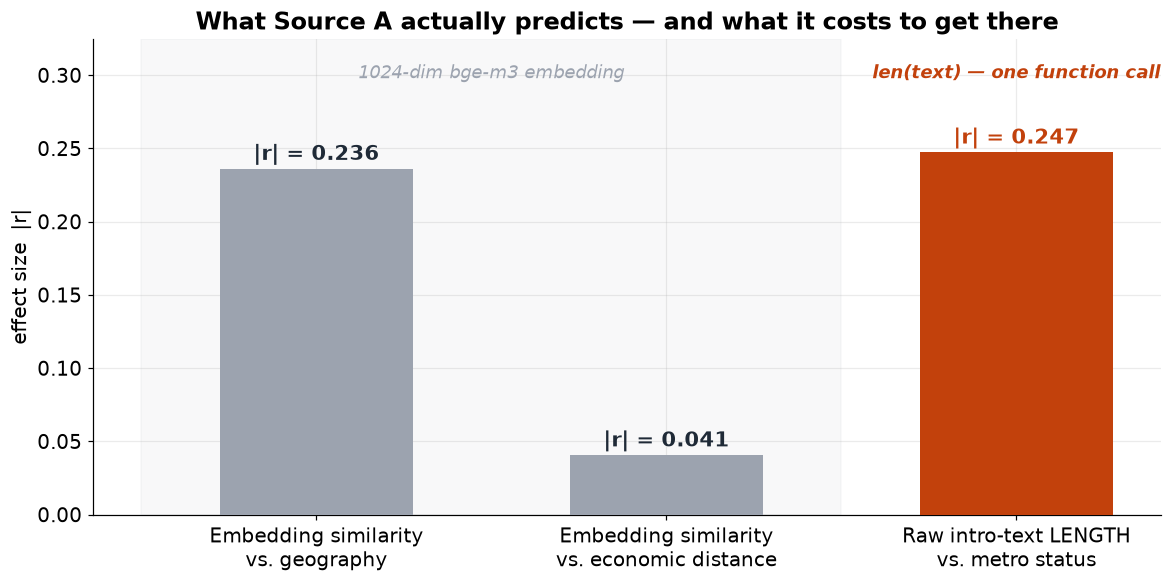

In [5]:
bars = pd.DataFrame([
    ("Embedding similarity\nvs. geography", abs(A_GEO_R), "expensive"),
    ("Embedding similarity\nvs. economic distance", abs(A_ECON_R), "expensive"),
    ("Raw intro-text LENGTH\nvs. metro status", abs(F_x_A_R), "free"),
], columns=["test", "abs_r", "cost"])

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [MUTED, MUTED, ACCENT]
ax.bar(bars["test"], bars["abs_r"], color=colors, width=0.55, zorder=3)

for x, (v, cost) in enumerate(zip(bars["abs_r"], bars["cost"])):
    ax.text(x, v + 0.006, f"|r| = {v:.3f}", ha="center", fontsize=14, fontweight="bold",
            color=ACCENT if cost == "free" else INK)

ax.set_ylabel("effect size  |r|")
ax.set_ylim(0, 0.325)
ax.set_title("What Source A actually predicts — and what it costs to get there")
ax.annotate("1024-dim bge-m3 embedding", xy=(0.5, 0.298), ha="center",
            fontsize=12, color=MUTED, style="italic")
ax.annotate("len(text) — one function call", xy=(2, 0.298), ha="center",
            fontsize=12, color=ACCENT, style="italic", fontweight="bold")
ax.axvspan(-0.5, 1.5, color=MUTED, alpha=0.07, zorder=0)
plt.tight_layout()
plt.show()

**Read it left to right.** The embedding does encode *geography* — counties
with similar text sit near each other on the map (|r| = 0.236). Against
*economics*, the same embedding collapses to |r| = 0.041: statistically
significant only because there are ~3.9M county pairs, and explaining well
under 1% of variance. Meanwhile `len(intro_text)` — no model, no GPU, no
2.2GB download — beats the embedding's economic signal by **6x** and edges out
its geographic signal too.

Supporting evidence: k-means on the embedding never finds structure. Silhouette
peaks at **0.028** (k=2) and stays flat through k=12 — a score of 0 means no
cluster structure at all.

**Verdict: cut the embedding, keep the source.** Wikipedia text stays in
`E_macro` as cheap scalar metadata (length, and later article age / edit
count). The `bge-m3` inference step comes out of the pipeline.

---

## 3. Source B — the wrong feature was being read

Source B gives each county a Location Quotient per NAICS sector: LQ = 2.0 means
twice the national-average job concentration. The obvious summary feature is
`dominant_lq` — *how specialized* a county is. That feature is nearly useless.

Below: every one of the 20 sectors correlated separately against GDP velocity,
499-permutation tested, Benjamini-Hochberg corrected across the full scan.

In [6]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
from analyze_source_b_industry_mix import LQ_COLUMNS, NAICS2_LABELS
from stats_utils import benjamini_hochberg, permutation_test_corr

bc = src["B"].merge(c[["fips_code", "gdp_velocity_pct"]], on="fips_code", how="inner")

rows = []
for col in LQ_COLUMNS:
    naics2 = col.replace("lq_emp_", "")
    sub = bc[[col, "gdp_velocity_pct"]].dropna()
    if len(sub) < 100:
        continue
    r, p = permutation_test_corr(sub[col], sub["gdp_velocity_pct"], 499, 42)
    rows.append({"sector": NAICS2_LABELS.get(naics2, naics2), "r": r, "p": p, "n": len(sub)})

sector_r = pd.DataFrame(rows)
sector_r["q"] = benjamini_hochberg(sector_r["p"].tolist())
sector_r = sector_r.sort_values("r").reset_index(drop=True)

MAGNITUDE_R = stats["B"]["dominant_lq_vs_gdp_velocity_pct_corr"]
print(f"{len(sector_r)} sectors tested | {(sector_r['q'] < 0.05).sum()} survive FDR q < 0.05")

20 sectors tested | 8 survive FDR q < 0.05


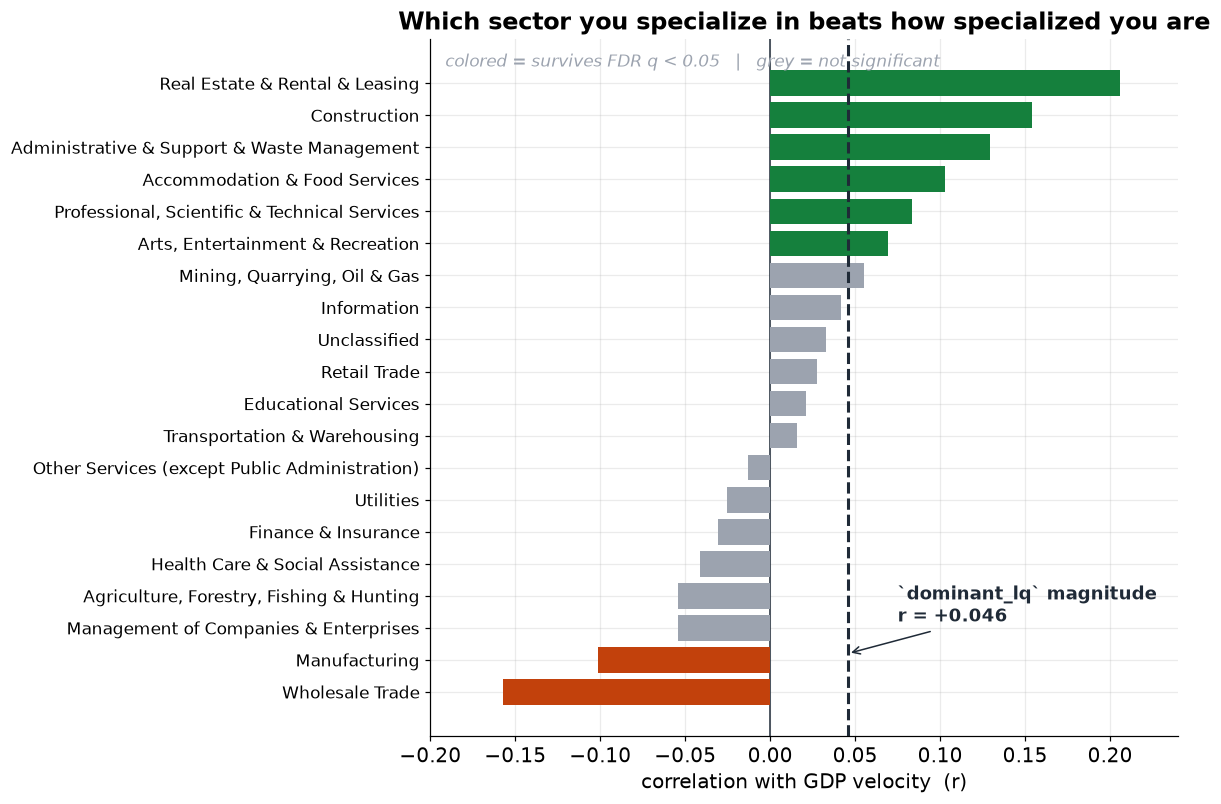

In [7]:
fig, ax = plt.subplots(figsize=(11, 7.5))
sig = sector_r["q"] < 0.05
colors = np.where(sig, np.where(sector_r["r"] > 0, GOOD, ACCENT), MUTED)

ax.barh(sector_r["sector"], sector_r["r"], color=colors, zorder=3)
ax.axvline(0, color=INK, lw=1)
ax.axvline(MAGNITUDE_R, color=INK, ls="--", lw=2, zorder=4)
ax.annotate(f"`dominant_lq` magnitude\nr = {MAGNITUDE_R:+.3f}",
            xy=(MAGNITUDE_R, 1.2), xytext=(0.075, 2.2), fontsize=12, fontweight="bold",
            color=INK, arrowprops=dict(arrowstyle="->", color=INK))

ax.set_xlabel("correlation with GDP velocity  (r)")
ax.set_title("Which sector you specialize in beats how specialized you are")
ax.set_xlim(-0.20, 0.24)
ax.tick_params(axis="y", labelsize=11)
ax.text(0.02, 0.96, "colored = survives FDR q < 0.05   |   grey = not significant",
        transform=ax.transAxes, ha="left", fontsize=11, color=MUTED, style="italic")
plt.tight_layout()
plt.show()

**Read the dashed line.** `dominant_lq` — the feature the pipeline currently
exposes — sits at r = +0.046, buried inside the noise band. Sector identity
spreads across a range **9x wider**: Real Estate & Rental & Leasing at
**+0.206**, Wholesale Trade at **-0.157**, Construction at **+0.154**, all
surviving FDR correction across the full 20-sector scan.

The sign flip matters as much as the magnitude. A county specialized in real
estate and a county specialized in wholesale trade are moving in *opposite*
economic directions — and `dominant_lq` scores them identically. This is the
distinction the proposal wanted from Source B ("what kind of growth"), and it
was invisible while the analysis stopped at the magnitude summary.

**Verdict: keep Source B, change the feature.** Ship the 20-dim LQ vector into
the fusion, not the scalar `dominant_lq`.

---

## 4. Source C — the hub has two defects

Source C is the designated hub: rolling 3-year first derivatives of county
unemployment and real GDP, the variable every other pillar is supposed to
explain. Two problems, both fixable, both currently baked into the parquet.

### 4a. GDP velocity is denominated in dollars, so it ranks size, not speed

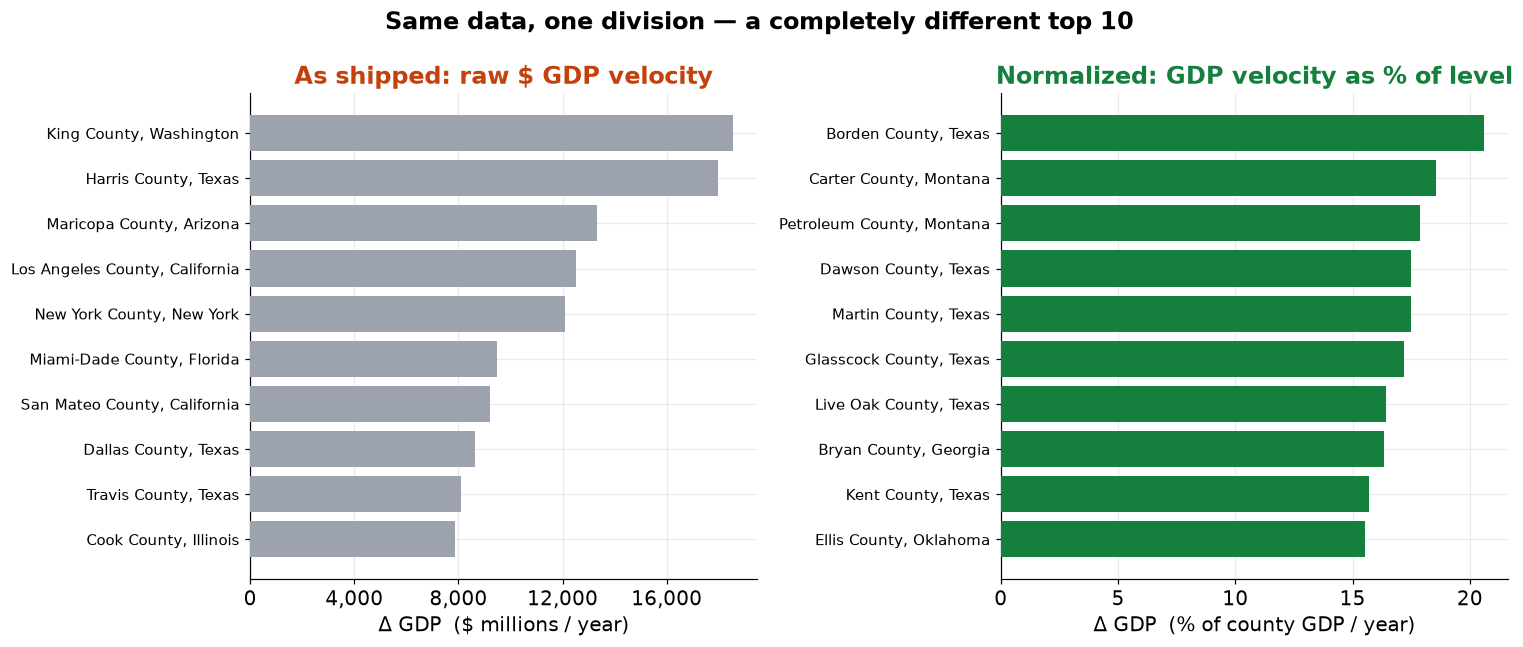

counties appearing in BOTH top-10 lists: 0


In [8]:
cc = src["C"].dropna(subset=["gdp_velocity", "gdp_latest"]).copy()
cc["gdp_velocity_pct"] = cc["gdp_velocity"] / cc["gdp_latest"]

raw_top = cc.nlargest(10, "gdp_velocity")[["county_name", "gdp_velocity"]]
pct_top = cc.nlargest(10, "gdp_velocity_pct")[["county_name", "gdp_velocity_pct"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(raw_top["county_name"][::-1], raw_top["gdp_velocity"][::-1] / 1e3,
             color=MUTED, zorder=3)
axes[0].set_title("As shipped: raw $ GDP velocity", color=ACCENT)
axes[0].set_xlabel("Δ GDP  ($ millions / year)")

axes[1].barh(pct_top["county_name"][::-1], pct_top["gdp_velocity_pct"][::-1] * 100,
             color=GOOD, zorder=3)
axes[1].set_title("Normalized: GDP velocity as % of level", color=GOOD)
axes[1].set_xlabel("Δ GDP  (% of county GDP / year)")

axes[0].xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
axes[0].xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
for ax in axes:
    ax.tick_params(axis="y", labelsize=10)

fig.suptitle("Same data, one division — a completely different top 10",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

overlap = set(raw_top["county_name"]) & set(pct_top["county_name"])
print(f"counties appearing in BOTH top-10 lists: {len(overlap)}")

The left list is a population ranking wearing a momentum costume — King,
Harris, Maricopa, Los Angeles. Of course the biggest economies add the most
dollars. The proposal's language is "momentum" and "fast movers"; the metric
as written answers "who is largest."

`gdp_velocity_pct = gdp_velocity / gdp_latest` fixes it. That line already
exists — but only *inside* three analysis scripts, recomputed locally each
time. It was never written back to `source_c_fred.parquet`, so any downstream
consumer reading the parquet gets the dollar-denominated version by default.

### 4b. The quadrant framing collapses into one box

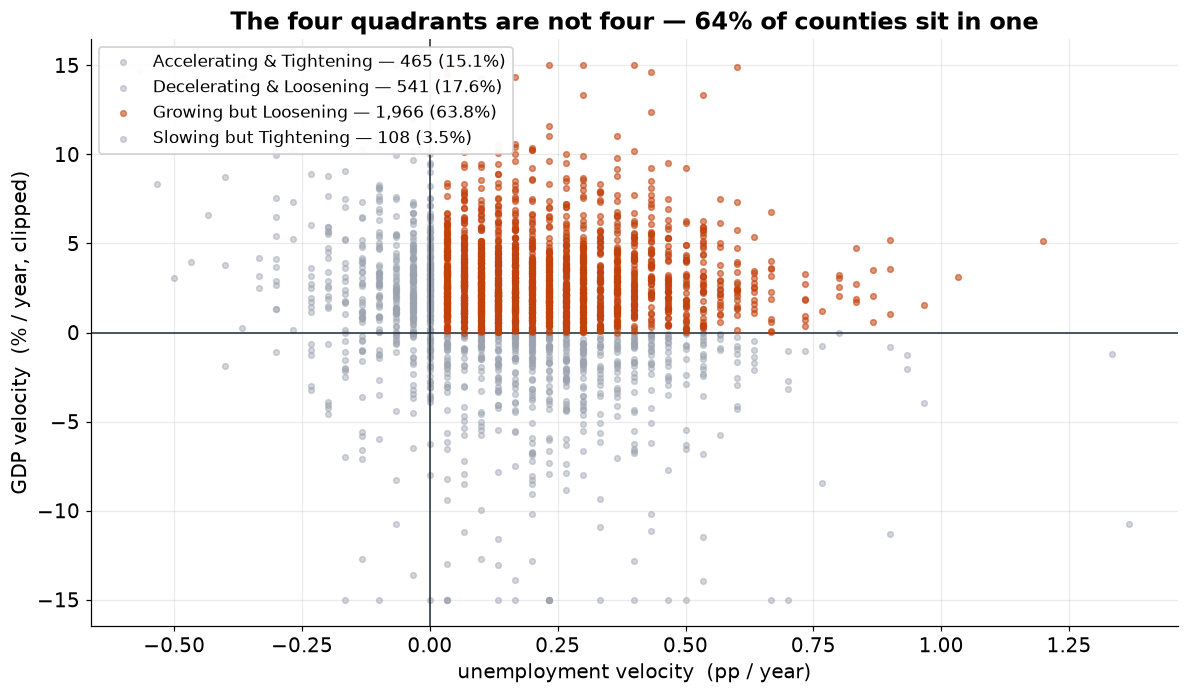

mean unemployment velocity: +0.19 pp/year
correlation between the two velocities: r = +0.009


In [9]:
q = src["C"].dropna(subset=["unemployment_velocity", "gdp_velocity"]).copy()
q["accelerating"] = q["gdp_velocity"] >= 0
q["tightening"] = q["unemployment_velocity"] <= 0
LABELS = {(True, True): "Accelerating & Tightening", (True, False): "Growing but Loosening",
          (False, True): "Slowing but Tightening", (False, False): "Decelerating & Loosening"}
q["quadrant"] = [LABELS[(a, t)] for a, t in zip(q["accelerating"], q["tightening"])]

counts = q["quadrant"].value_counts()
dominant = "Growing but Loosening"

fig, ax = plt.subplots(figsize=(11, 6.5))
for label, grp in q.groupby("quadrant"):
    is_dom = label == dominant
    ax.scatter(grp["unemployment_velocity"],
               (grp["gdp_velocity"] / grp["gdp_latest"]).clip(-0.15, 0.15) * 100,
               s=14, alpha=0.55 if is_dom else 0.45,
               color=ACCENT if is_dom else MUTED, zorder=3 if is_dom else 2,
               label=f"{label} — {counts[label]:,} ({counts[label]/len(q):.1%})")

ax.axhline(0, color=INK, lw=1)
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("unemployment velocity  (pp / year)")
ax.set_ylabel("GDP velocity  (% / year, clipped)")
ax.set_title("The four quadrants are not four — 64% of counties sit in one")
ax.legend(loc="upper left", fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"mean unemployment velocity: {q['unemployment_velocity'].mean():+.2f} pp/year")
print(f"correlation between the two velocities: r = {stats['C']['velocity_correlation']:+.3f}")

The proposal expected counties to distribute across four momentum regimes.
They don't: **63.8%** land in "Growing but Loosening" — GDP still rising while
unemployment also rises — and mean unemployment velocity is **+0.19 pp/year**
almost everywhere. The two velocities are effectively independent
(**r = 0.009**).

That pattern is a national level shift — labor markets normalizing upward off
historically low 2022 unemployment while GDP keeps growing — not a variable
that separates fast counties from slow ones. Which is exactly why every pillar
correlates so weakly against it (Section 8).

**Verdict: keep Source C, fix the metric.** Write `gdp_velocity_pct` back to
the parquet, and stop treating the quadrant label as a discriminating feature.

---

## 5. Sources D & E — weak, but clean and independent

Two pillars, two completely unrelated data providers, same shape of result:
sort counties into quartiles and mean GDP velocity climbs monotonically.
Neither is a strong predictor. Both are honest ones.

- **D** — BTS freight tonnage (in + out), the "movement" pillar
- **E** — IRS capital gains + dividends over wages, the "capital flow" pillar

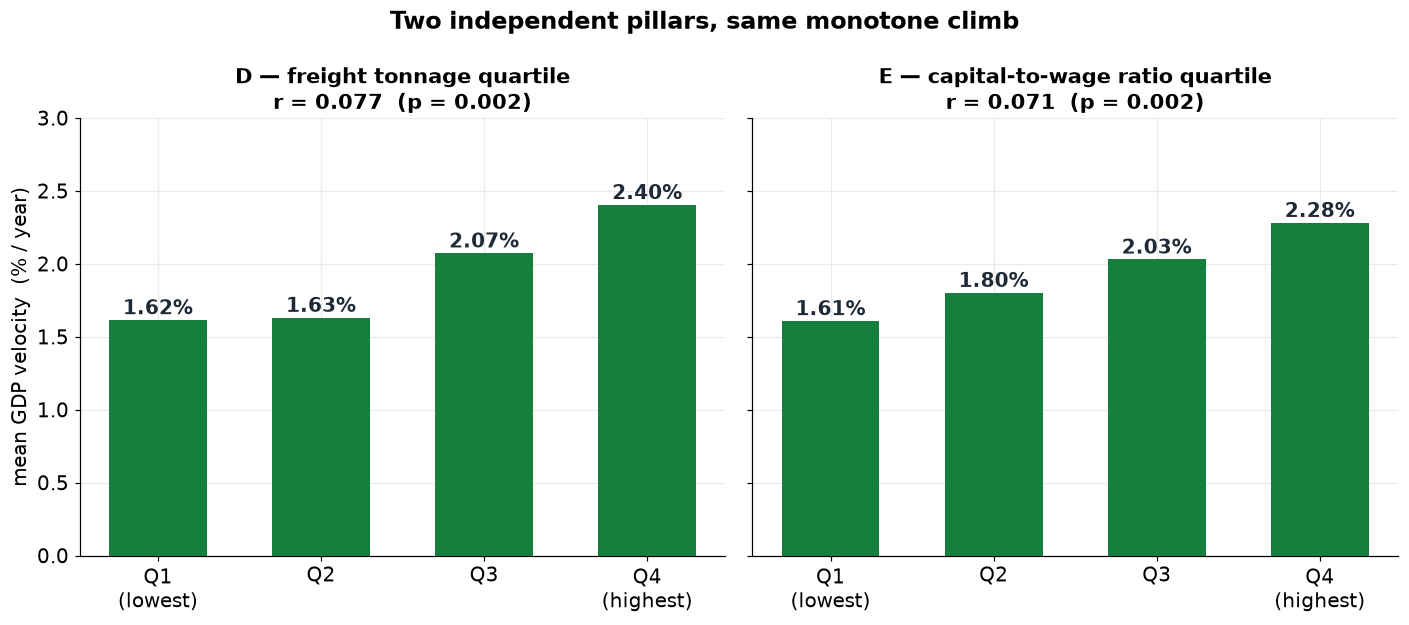

In [10]:
QUARTILE_LABELS = ["Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)"]

de = panel.dropna(subset=["gdp_velocity_pct"]).copy()
de["tons_quartile"] = pd.qcut(de["total_tons"], 4, labels=[1, 2, 3, 4])
de["capital_quartile"] = pd.qcut(de["capital_to_wage_ratio"], 4, labels=[1, 2, 3, 4])

tons_means = de.groupby("tons_quartile", observed=True)["gdp_velocity_pct"].mean() * 100
cap_means = de.groupby("capital_quartile", observed=True)["gdp_velocity_pct"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True)
panels = [
    (axes[0], tons_means, "D — freight tonnage quartile",
     f"r = {stats['D']['log_tons_vs_gdp_velocity_pct_corr']:.3f}  "
     f"(p = {stats['D']['log_tons_vs_gdp_velocity_pct_p']:.3f})"),
    (axes[1], cap_means, "E — capital-to-wage ratio quartile",
     f"r = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_corr']:.3f}  "
     f"(p = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_p']:.3f})"),
]

for ax, means, title, subtitle in panels:
    ax.bar(QUARTILE_LABELS, means.values, color=GOOD, width=0.6, zorder=3)
    for x, v in enumerate(means.values):
        ax.text(x, v + 0.04, f"{v:.2f}%", ha="center", fontsize=13, fontweight="bold", color=INK)
    ax.set_title(f"{title}\n{subtitle}", fontsize=14)
    ax.set_ylim(0, 3.0)

axes[0].set_ylabel("mean GDP velocity  (% / year)")
fig.suptitle("Two independent pillars, same monotone climb", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Both climb, neither steeply.** Freight moves mean GDP velocity from
**1.62% → 2.40%** across quartiles; capital composition from
**1.61% → 2.28%**. The underlying correlations are small — r = 0.077 and
r = 0.071 — but both are permutation-significant at p = 0.002, both are
monotone with no reversal, and they come from datasets that share nothing:
truck tonnage from BTS versus tax returns from the IRS.

Two caveats worth saying out loud before your boss finds them:

- **D lost its dollar column.** Both scoping docs describe Source D as tracking
  tonnage *and* dollar value; the experimental county-level product ships
  tonnage only. A county moving gravel and a county moving semiconductors look
  identical here.
- **E's tail is noise.** Seven of the top-25 capital-ratio counties have fewer
  than 2,200 tax returns — Arthur County NE (190 returns), Garfield County MT
  (550). Their ratios are single land sales, not investment economies. Weight
  by `num_returns` downstream or the tail will mislead.

**Verdict: keep both.** D is the most consistently significant pillar against
Source C. E needs return-weighting before it enters the fusion.

---

## 6. Source F — dead against the hub, alive against a pillar

Source F is USDA's county typology: industry dependence plus six demographic
risk flags (population loss, persistent poverty, low employment, housing
stress, low postsecondary education, retirement destination). Summed, those
flags give each county a distress count from 0 to 5.

Same variable, two tests. Left is the test the proposal specified. Right is
the test nobody ran until Round 2.

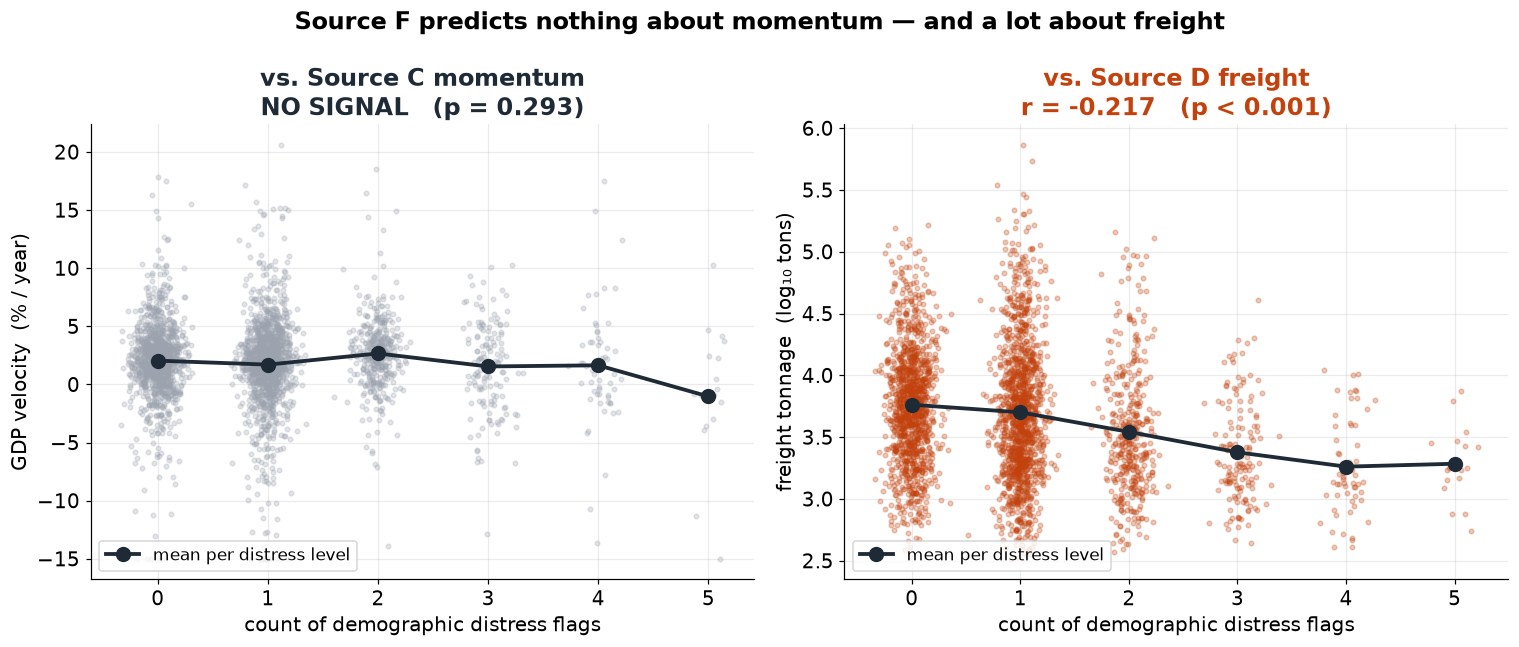

In [11]:
rng = np.random.default_rng(42)
fx = panel.dropna(subset=["gdp_velocity_pct"])
gx = panel.dropna(subset=["log_tons"])

r_vel, p_vel = pearsonr(fx["distress_count"], fx["gdp_velocity_pct"])
r_tons, p_tons = pearsonr(gx["distress_count"], gx["log_tons"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sub, ycol, yscale, ylabel, title, r, p, color in [
    (axes[0], fx, "gdp_velocity_pct", 100, "GDP velocity  (% / year)",
     "vs. Source C momentum", r_vel, p_vel, MUTED),
    (axes[1], gx, "log_tons", 1, "freight tonnage  (log\u2081\u2080 tons)",
     "vs. Source D freight", r_tons, p_tons, ACCENT),
]:
    jitter = rng.normal(0, 0.11, len(sub))
    y = (sub[ycol] * yscale).clip(-15, None) if yscale == 100 else sub[ycol]
    ax.scatter(sub["distress_count"] + jitter, y, s=9, alpha=0.28, color=color, zorder=2)

    means = sub.groupby("distress_count")[ycol].mean() * yscale
    ax.plot(means.index, means.values, "o-", color=INK, lw=2.5, ms=9, zorder=4,
            label="mean per distress level")

    verdict = "NO SIGNAL" if p > 0.05 else f"r = {r:.3f}"
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.set_title(f"{title}\n{verdict}   ({p_text})",
                 color=INK if p > 0.05 else ACCENT)
    ax.set_xlabel("count of demographic distress flags")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(6))
    ax.legend(loc="lower left", fontsize=11)

fig.suptitle("Source F predicts nothing about momentum — and a lot about freight",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Left panel: a flat line.** Stack distress flags on a county and its GDP
velocity does not move (r = -0.019, p = 0.29). Against unemployment velocity
it is worse — p = 0.72. By the standard the proposal set, Source F fails
outright.

**Right panel: a real slope.** The same distress count against freight
tonnage gives **r = -0.217, p = 0.002** — more than 2.5x the size of *any*
pillar-vs-Source-C link in this entire project. Distressed counties move
measurably less freight, and the mean drops cleanly at every step from 0 to 5
flags.

Source F isn't a weak pillar. It was being asked the wrong question. It
measures *structural* character — what a county is — not *momentum* — where a
county is heading this year. Those are different axes, and the proposal
assumed they were the same one.

**Verdict: keep Source F, reclassify it.** It enters the fusion as a
structural covariate and a stratification variable, not as a momentum
predictor.

---

## 7. The reframe — the hub model is what's underperforming

Every section above tested a pillar against Source C, because that is the
architecture the proposal specifies: Source C is the hub, every other pillar
explains a slice of it. Here is every crossvalidation this project has run,
on one axis.

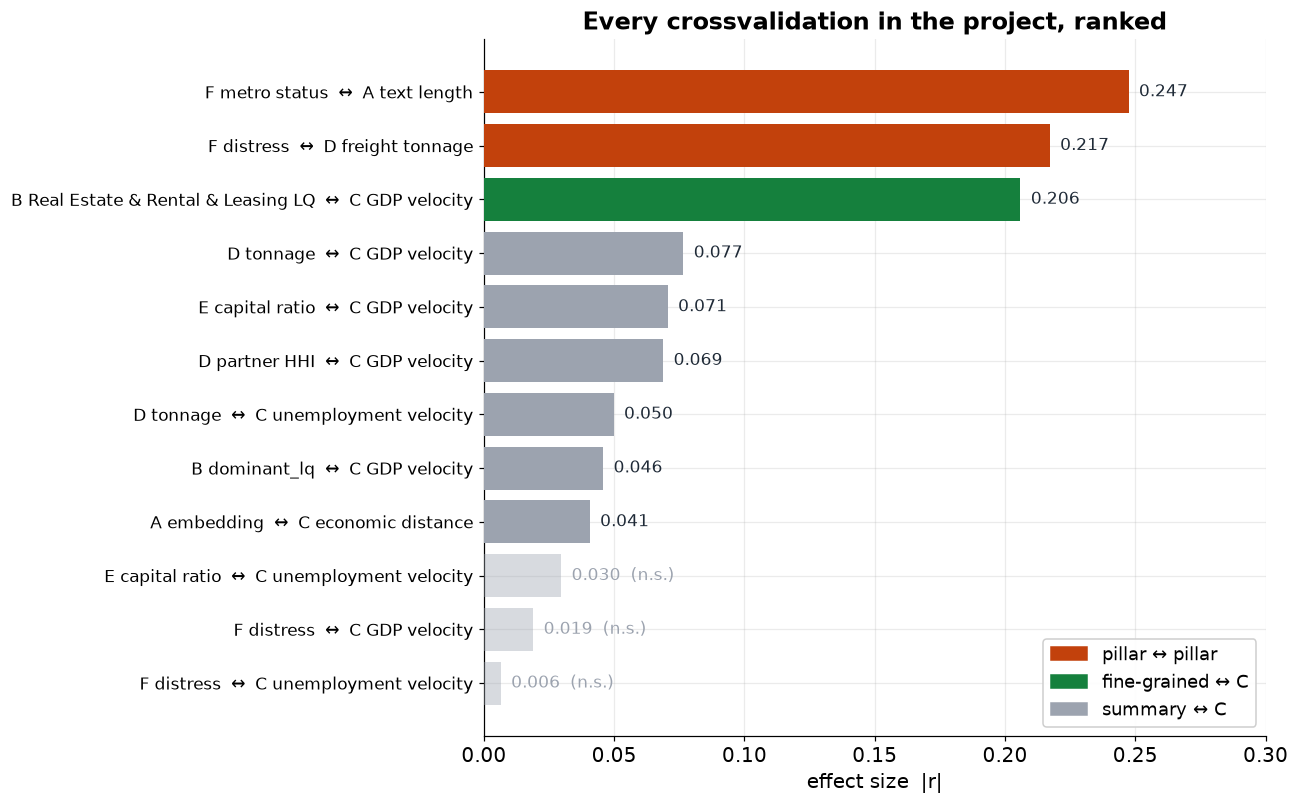

In [12]:
BEST_SECTOR_LABEL = sector_r.iloc[sector_r["r"].abs().idxmax()]["sector"]
BEST_SECTOR_R = sector_r["r"].abs().max()

tests = pd.DataFrame([
    ("F distress  ↔  D freight tonnage",        abs(F_x_D_R), "pillar ↔ pillar", True),
    ("F metro status  ↔  A text length",        abs(F_x_A_R), "pillar ↔ pillar", True),
    (f"B {BEST_SECTOR_LABEL} LQ  ↔  C GDP velocity", BEST_SECTOR_R, "fine-grained ↔ C", True),
    ("D tonnage  ↔  C GDP velocity",
     abs(stats["D"]["log_tons_vs_gdp_velocity_pct_corr"]), "summary ↔ C", True),
    ("E capital ratio  ↔  C GDP velocity",
     abs(stats["E"]["capital_to_wage_ratio_vs_gdp_velocity_pct_corr"]), "summary ↔ C", True),
    ("D partner HHI  ↔  C GDP velocity",
     abs(stats["D"]["hhi_vs_gdp_velocity_pct_corr"]), "summary ↔ C", True),
    ("D tonnage  ↔  C unemployment velocity",
     abs(stats["D"]["log_tons_vs_unemployment_velocity_corr"]), "summary ↔ C", True),
    ("B dominant_lq  ↔  C GDP velocity",
     abs(stats["B"]["dominant_lq_vs_gdp_velocity_pct_corr"]), "summary ↔ C", True),
    ("A embedding  ↔  C economic distance",     abs(A_ECON_R), "summary ↔ C", True),
    ("E capital ratio  ↔  C unemployment velocity",
     abs(stats["E"]["capital_to_wage_ratio_vs_unemployment_velocity_corr"]), "summary ↔ C", False),
    ("F distress  ↔  C GDP velocity",
     abs(stats["F"]["distress_vs_gdp_velocity_pct_corr"]), "summary ↔ C", False),
    ("F distress  ↔  C unemployment velocity",
     abs(stats["F"]["distress_vs_unemployment_velocity_corr"]), "summary ↔ C", False),
], columns=["test", "abs_r", "kind", "significant"]).sort_values("abs_r")

KIND_COLORS = {"pillar ↔ pillar": ACCENT, "fine-grained ↔ C": GOOD, "summary ↔ C": MUTED}

fig, ax = plt.subplots(figsize=(12, 7.5))
bar_colors = [mpl.colors.to_rgba(KIND_COLORS[k], 1.0 if s else 0.4)
              for k, s in zip(tests["kind"], tests["significant"])]
ax.barh(tests["test"], tests["abs_r"], color=bar_colors, zorder=3)

for y, (v, s) in enumerate(zip(tests["abs_r"], tests["significant"])):
    ax.text(v + 0.004, y, f"{v:.3f}" + ("" if s else "  (n.s.)"),
            va="center", fontsize=11, color=INK if s else MUTED)

ax.set_xlabel("effect size  |r|")
ax.set_xlim(0, 0.30)
ax.set_title("Every crossvalidation in the project, ranked")
handles = [mpl.patches.Patch(color=col, label=lab) for lab, col in KIND_COLORS.items()]
ax.legend(handles=handles, loc="lower right", fontsize=12, framealpha=0.95)
ax.tick_params(axis="y", labelsize=11)
plt.tight_layout()
plt.show()

**The bottom nine bars are the architecture as designed.** Pillar summary
feature against Source C: nothing clears |r| = 0.08, and three of them are not
significant at all.

**The top three bars are everything that worked** — and none of them is the
designed test:

| rank | test | \|r\| | what changed |
|---|---|---|---|
| 1 | F metro ↔ A text length | 0.247 | pillar talks to pillar, Source C not involved |
| 2 | F distress ↔ D freight | 0.217 | pillar talks to pillar, Source C not involved |
| 3 | B Real Estate LQ ↔ C GDP velocity | 0.206 | still uses C, but a *sector-level* feature instead of a summary scalar |

Two independent escape routes out of the noise floor, and the failing element
is common to both: **collapsing a pillar to one summary number, then regressing
it on a hub variable that is itself 64% one value.**

This is why the honest read of the six pillars is not "four are weak." It is
"the test was underpowered by construction." Source F looked like the weakest
pillar in the program right up until it was tested against something other
than Source C, at which point it produced the two largest effects on the board.

---

## 8. Recommendation

Nothing gets deleted. One expensive component gets cut, three pillars get
feature changes, and the crossvalidation architecture gets rescoped.

In [13]:
actions = pd.DataFrame([
    ("A — Wikipedia", "CUT",
     "Drop the bge-m3 embedding step. Keep intro text as cheap scalars "
     "(length now; article age / edit count later)."),
    ("B — QCEW", "FIX",
     "Ship the 20-dim LQ vector into the fusion instead of the `dominant_lq` scalar."),
    ("C — FRED", "FIX",
     "Write `gdp_velocity_pct` back to the parquet. Stop treating the quadrant "
     "label as a discriminating feature."),
    ("D — FAF freight", "KEEP",
     "No change. Document the missing dollar-value column as an accepted "
     "upstream limitation."),
    ("E — IRS SOI", "FIX",
     "Weight by `num_returns`, or flag counties under ~2,200 returns, before fusion."),
    ("F — USDA typology", "KEEP",
     "Reclassify as a structural covariate and stratification variable — not a "
     "momentum predictor."),
    ("Crossvalidation design", "RESCOPE",
     "Test pillar pairs directly. The full 15-pair sweep has never been run; "
     "the 2 pairs tested produced the 2 largest effects in the project."),
], columns=["Target", "Action", "What it means"])

ACTION_STYLE = {
    "CUT": "background-color: #fee2e2; color: #991b1b; font-weight: 700",
    "FIX": "background-color: #fef3c7; color: #92400e; font-weight: 700",
    "KEEP": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "RESCOPE": "background-color: #dbeafe; color: #1e40af; font-weight: 700",
}

(actions.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top",
                       "font-size": "13px", "padding": "10px"})
    .set_properties(subset=["Target"], **{"font-weight": "700"})
    .map(lambda v: ACTION_STYLE.get(v, ""), subset=["Action"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "10px")]},
    ])
    .set_caption("What changes, per pillar"))

Target,Action,What it means
A — Wikipedia,CUT,Drop the bge-m3 embedding step. Keep intro text as cheap scalars (length now; article age / edit count later).
B — QCEW,FIX,Ship the 20-dim LQ vector into the fusion instead of the `dominant_lq` scalar.
C — FRED,FIX,Write `gdp_velocity_pct` back to the parquet. Stop treating the quadrant label as a discriminating feature.
D — FAF freight,KEEP,No change. Document the missing dollar-value column as an accepted upstream limitation.
E — IRS SOI,FIX,"Weight by `num_returns`, or flag counties under ~2,200 returns, before fusion."
F — USDA typology,KEEP,Reclassify as a structural covariate and stratification variable — not a momentum predictor.
Crossvalidation design,RESCOPE,Test pillar pairs directly. The full 15-pair sweep has never been run; the 2 pairs tested produced the 2 largest effects in the project.


### Order of work

1. **Write `gdp_velocity_pct` back to `source_c_fred.parquet`** — one line,
   ~10 minutes. Every downstream consumer currently reads a size-confounded
   metric by default. Highest ratio of impact to effort in the list.
2. **Run the full 15-pair pillar crossvalidation** — ~1–2 days. Two of fifteen
   pairs have been tested and both beat everything else in the project. The
   remaining thirteen are the cheapest place left to find real signal.
3. **Swap Source B to the 20-dim LQ vector** — ~half a day. Recovers a
   0.206 effect that the current scalar feature discards.
4. **Weight Source E by `num_returns`** — ~1 hour. Prevents the low-return
   tail from entering the fusion as if it were signal.
5. **Remove the embedding step from Source A ingestion** — ~half a day.
   Deletes a 2.2GB model download and CPU inference over 3,144 articles from
   every pipeline run, and costs nothing measurable in predictive power.

### What this is *not*

No pillar is being dropped. Coverage is 3,143–3,144 counties on five of six
sources, the ingestion is stable, and every defect above is a feature-choice
or architecture problem rather than a data-collection failure. The dataset is
sound; what needs revising is the model of how the pillars relate to each
other.